(example_combatgam_imbalance_across_sites)=

# Analasing neuroComBat behaivor when imbalance across sites.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from uniharmony import verbosity
from uniharmony.combat import ComBatGAM
from uniharmony.datasets import make_multisite_classification


sns.set_theme(style="whitegrid")
verbosity("warning")

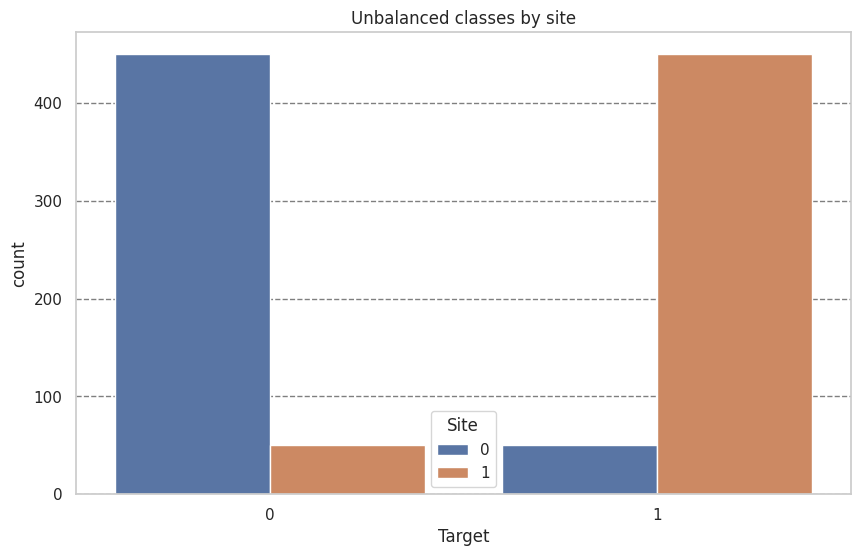

In [2]:
X, y, sites = make_multisite_classification(
    n_features=2,
    signal_strength=2,
    site_effect_strength=0,  # NO site effect
    balance_per_site=[0.1, 0.9],
)
df = pd.DataFrame({"Target": y, "Site": sites})

plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

## Note that we are harmonizing the whole dataset, which must be avoided in ML scenarios.
## This is just to illustrate the effect of harmonization.

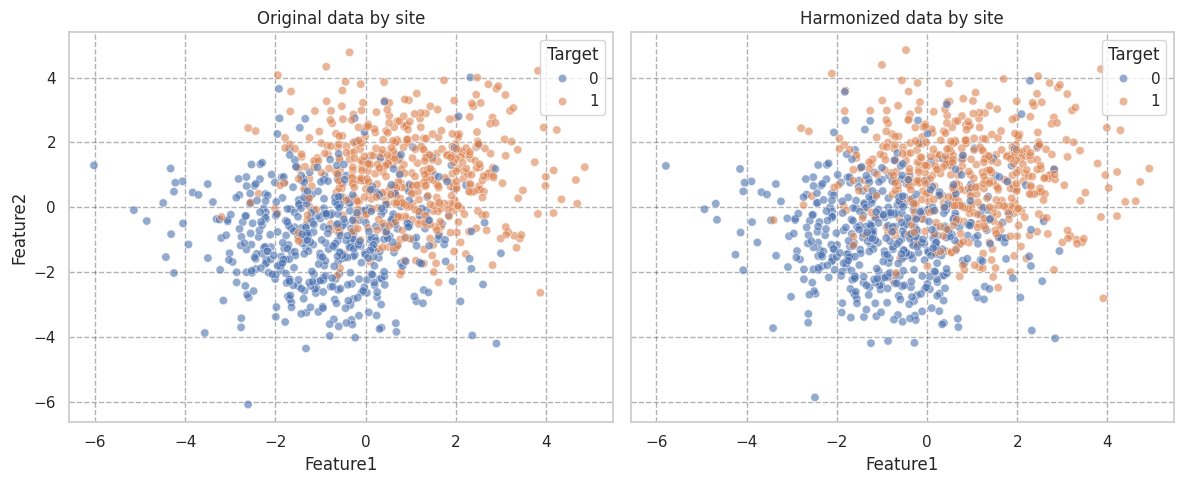

In [3]:
# Note that we are harmonizing the whole dataset, which is not how it would be used in practice.
# This is just to illustrate the effect of harmonization.
combat = ComBatGAM()
combat.fit(X, sites, smooth_covariates=y.reshape(-1, 1))
X_harmonized = combat.transform(X, sites, smooth_covariates=y.reshape(-1, 1))

df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Target"] = y
df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites
df_harm["Target"] = y
df_harm["Phase"] = "Harmonized"


fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Target", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
axes[0].grid(alpha=0.3, color="black", linestyle="--")

sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Target", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
axes[1].grid(alpha=0.3, color="black", linestyle="--")
plt.tight_layout()

## Example preserving the target as covariate.
### This is also wrong in ML context, where you don't have access to the full dataset but may be a good option for statistical analysis.

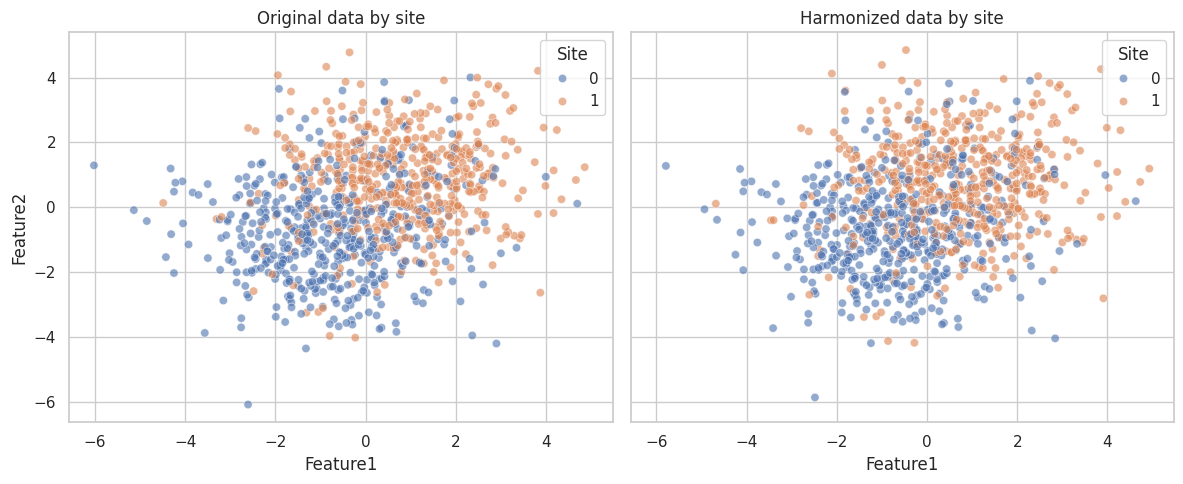

In [4]:
combat = ComBatGAM()
# This is the key line: we need to include the target variable as a covariate
# to preserve its relationship with the features during harmonization.

combat.fit(X, sites, smooth_covariates=y.reshape(-1, 1))
X_harmonized = combat.transform(X, sites, smooth_covariates=y.reshape(-1, 1))

df_orig = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_orig["Site"] = sites
df_orig["Target"] = y

df_orig["Phase"] = "Original"

df_harm = pd.DataFrame(X_harmonized, columns=["Feature1", "Feature2"])
df_harm["Site"] = sites
df_harm["Target"] = y

df_harm["Phase"] = "Harmonized"

# Plot data distribution by site before and after harmonization
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
sns.scatterplot(data=df_orig, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[0])
axes[0].set_title("Original data by site")
sns.scatterplot(data=df_harm, x="Feature1", y="Feature2", hue="Site", alpha=0.6, ax=axes[1])
axes[1].set_title("Harmonized data by site")
plt.tight_layout()

## Take-home message
### ComBat cannot preserve the target variance in class imbalance scenarios unless we preserve it as covariate.
### Note that preserving the target as covariate may be suited for statistical analysis, but not for ML scenarios.
### The method warn us about the preservation of a covariate.